<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 5</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Parsa Saeednia <br>
        <b>🆔 Student ID:</b> 810102460 <br><br>
        <h5 style="color: #1a365d;"> TASK 2 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 5 - Task 2. It focuses on evaluating semantic equivalence between formal and informal Persian sentences using the ParsMap dataset. The implementation covers training custom Word2Vec models, extracting contextual representations via ParsBERT, visualizing embedding alignments using non-linear dimensionality reduction, and training a binary classifier to detect semantic similarity.
</div>

## Table of Contents
1. [Dataset Loading & Word2Vec Static Embedding Training](#word2vec-training)
2. [ParsBERT Contextual Embeddings & Sentence Representation](#parsbert-embeddings)
3. [Dimensionality Reduction (PCA, t-SNE/UMAP) & Alignment Visualization](#visualization)
4. [Balanced Binary Dataset Creation & Classification Pipeline](#classification)
5. [Comparative Analysis (Word2Vec vs. ParsBERT)](#evaluation)

<a id="word2vec-training"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Dataset Loading & Word2Vec Static Embedding Training</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We load the Persian ParsMap dataset and clean the formal and informal text fields. A static vector space is constructed by training a custom <code>Word2Vec</code> model using the <code>gensim</code> library (comparing CBOW and Skip-Gram configurations). Semantic representation quality is evaluated by extracting cosine similarities for nearest-neighbor words.
</div>


In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

def load_and_explore_data(file_path):
    df = pd.read_excel(file_path)
    
    if not {'formalForm', 'inFormalForm'}.issubset(df.columns):
        raise ValueError(f"Dataset columns found: {list(df.columns)}. Must contain 'formalForm' and 'inFormalForm'.")
        
    print(f"Total sentence pairs in the dataset: {len(df)}\n")
    
    sample_df = df.sample(n=5, random_state=42)
    
    for index, row in sample_df.iterrows():
        print(f"--- Pair {index} ---")
        print(f"Formal:   {row['formalForm']}")
        print(f"Informal: {row['inFormalForm']}\n")
        
    return df

df = load_and_explore_data('data/trainset_40k_onlySent.xlsx')

Total sentence pairs in the dataset: 40018

--- Pair 22949 ---
Formal:   همسر من نه اخلاق دارد، نه صله‌رحم دارد و نه احساس دارد و خیلی کم پیش می‌آید که در خانۀ من مهمان بیاید و من واقعاً دلم می‌گیرد.
Informal: همسر من نه اخلاق داره ن صله رحم داره ن احساس داره و توخونه من خیلی کم پیش میاد مهمون بیاد ومن واقعا دلم میگیره.

--- Pair 22690 ---
Formal:   با صدای در، هر دوی ما متعجب به طرف در برگشتیم.
Informal: با صدای در هر دوتامون متعجب برگشتیم طرف در

--- Pair 2299 ---
Formal:   وقتی سینا هم ببیند نرفته‌ام ول می‌کند و می‌رود.
Informal: سینا هم وقتی ببینه نرفتم ول میکنه و میره

--- Pair 8671 ---
Formal:   یعنی حتماً باید به دوا و درمان متوسل بشوم؟
Informal: یعنی حتما باید متوسل به دوادرمون بشم؟

--- Pair 29288 ---
Formal:   دلم می‌خواهد سرم را روی شانه‌ات بگذارم، روی سینه‌ات، روی زانویت، چه می‌دانم دیگر پیش تو باشم و زارزار مثل باران گریه کنم.
Informal: دلم میخواد سرمو بذارم روی شونت، روی سـینت، روی زانـوت چـه میـدونم پیشت باشم دیگه و زار زار گریه کنم مثل بارون



## linguistic modification
---

Based on the 5 sampled pairs from ParsMap, we can document several key linguistic mechanisms driving the transition from formal to informal Persian:

- **Phonological Vowel Shifts** ($/a:/ \rightarrow /u:/$): Systematic conversion of standard long vowels to colloquial rounded vowels
  - Example: `مهمون ← مهمان`
  - Example: `شونت ← شانه‌ات`
  - Example: `درمون ← درمان`

- **Verb Suffix and Stem Contraction**: Simplification of formal verbal endings and auxiliary forms
  - Example: `داره ← دارد`
  - Example: `ببینه ← ببیند`
  - Example: `بشم ← بشوم`
  - Example: `میره ← می‌رود`

- **Object Marker and Clitic Merging**: Direct object markers (`را`) and possessive pronouns are attached directly as clitics to nouns
  - Example: `سرمو ← سرم را`
  - Example: `پیشت ← پیش تو`

- **Prepositional and Orthographic Modifications**: Prepositions shift to colloquial equivalents or merge with adjacent words, along with orthographic space reduction
  - Example: `توخونه ← در خانه`
  - Example: `ومن ← و من`
  - Example: `ن ← نه`

- **Syntactic Reordering**: Words and prepositional phrases are repositioned for conversational flow
  - Example: `برگشتیم طرف در ← به طرف در برگشتیم`


=================== Sentence Length Statistics ===================
                      mean    std  min  median    max
formal_word_count    12.34   6.50  1.0    11.0   67.0
informal_word_count  11.39   6.53  1.0    10.0   64.0
formal_char_count    62.62  31.99  9.0    56.0  322.0
informal_char_count  55.08  30.05  5.0    48.0  320.0



C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_11028\2069098391.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(['Formal', 'Informal'])
C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_11028\2069098391.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(['Formal', 'Informal'])


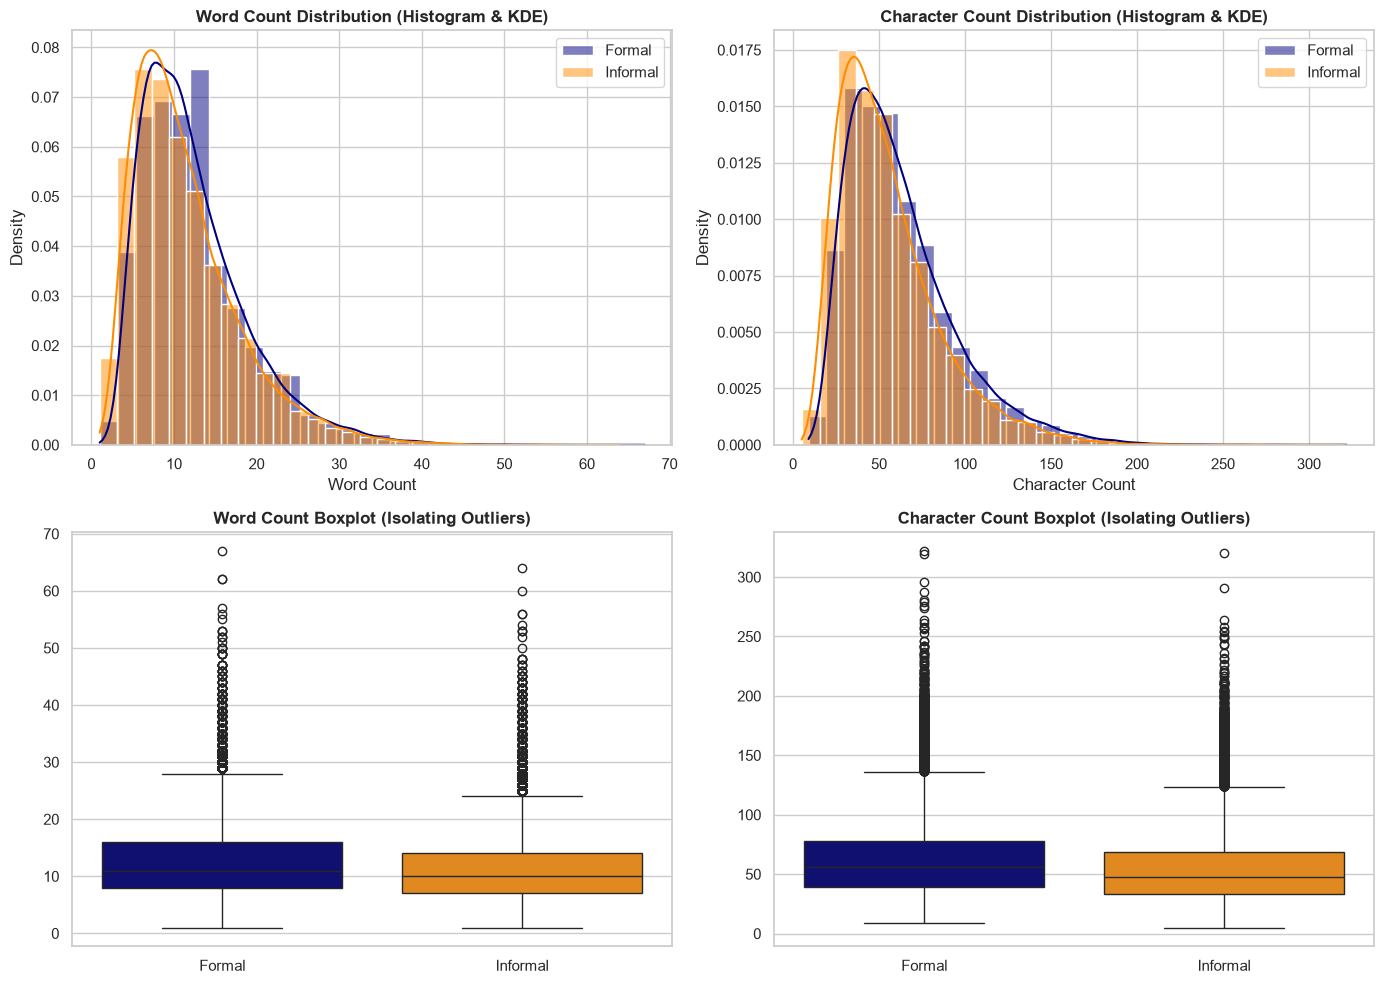

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

def analyze_sentence_lengths(df):
    df['formal_word_count'] = df['formalForm'].astype(str).apply(lambda x: len(x.split()))
    df['informal_word_count'] = df['inFormalForm'].astype(str).apply(lambda x: len(x.split()))
    df['formal_char_count'] = df['formalForm'].astype(str).apply(len)
    df['informal_char_count'] = df['inFormalForm'].astype(str).apply(len)
    
    cols = ['formal_word_count', 'informal_word_count', 'formal_char_count', 'informal_char_count']
    summary_stats = df[cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
    summary_stats.rename(columns={'50%': 'median'}, inplace=True)
    
    print("=================== Sentence Length Statistics ===================")
    print(summary_stats.round(2))
    print("=================================================================\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.histplot(df['formal_word_count'], color='navy', label='Formal', kde=True, ax=axes[0, 0], stat='density', common_norm=False, bins=30)
    sns.histplot(df['informal_word_count'], color='darkorange', label='Informal', kde=True, ax=axes[0, 0], stat='density', common_norm=False, bins=30)
    axes[0, 0].set_title("Word Count Distribution (Histogram & KDE)", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Word Count")
    axes[0, 0].legend()
    sns.histplot(df['formal_char_count'], color='navy', label='Formal', kde=True, ax=axes[0, 1], stat='density', common_norm=False, bins=30)
    sns.histplot(df['informal_char_count'], color='darkorange', label='Informal', kde=True, ax=axes[0, 1], stat='density', common_norm=False, bins=30)
    axes[0, 1].set_title("Character Count Distribution (Histogram & KDE)", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Character Count")
    axes[0, 1].legend()
    sns.boxplot(data=df[['formal_word_count', 'informal_word_count']], palette=['navy', 'darkorange'], ax=axes[1, 0])
    axes[1, 0].set_title("Word Count Boxplot (Isolating Outliers)", fontsize=12, fontweight='bold')
    axes[1, 0].set_xticklabels(['Formal', 'Informal'])
    sns.boxplot(data=df[['formal_char_count', 'informal_char_count']], palette=['navy', 'darkorange'], ax=axes[1, 1])
    axes[1, 1].set_title("Character Count Boxplot (Isolating Outliers)", fontsize=12, fontweight='bold')
    axes[1, 1].set_xticklabels(['Formal', 'Informal'])
    
    plt.tight_layout()
    plt.show()
    
    return df

df = analyze_sentence_lengths(df)

The statistics clearly illustrate the structural compression inherent in conversational Persian:

- **Word Count Shift**: The mean word count drops from 12.34 (formal) to 11.39 (informal).
- **Character Count Shift**: The mean character count drops even more sharply from 62.62 to 55.08.

**Why does this reduction occur?**

- **Clitic & Marker Merging**: In formal Persian, structural markers like `را` and possessive pronouns are separated by spaces or half-spaces. Informal Persian attaches these directly as clitics, reducing both whitespace token count and overall character count.
  - Example: `سرمو ← سرم را`
  - Example: `پیشت ← پیش تو`

- **Vowel and Suffix Shortening**: Verbal suffixes and prepositions frequently drop letters or contract into shorter phonetic forms.
  - Example: `داره ← دارد`
  - Example: `تو ← در`
  - Example: `ه ← است`

- **Ellipsis of Non-Essential Tokens**: Informal registers naturally omit redundant formal markers and auxiliary prepositions without losing core intent.


=================== Vocabulary Statistics ===================
Total Formal Tokens:           561,248
Total Informal Tokens:         461,073
Formal Vocabulary Size:        25,800
Informal Vocabulary Size:      46,258
Unique to Formal Register:     10,718
Unique to Informal Register:   31,176



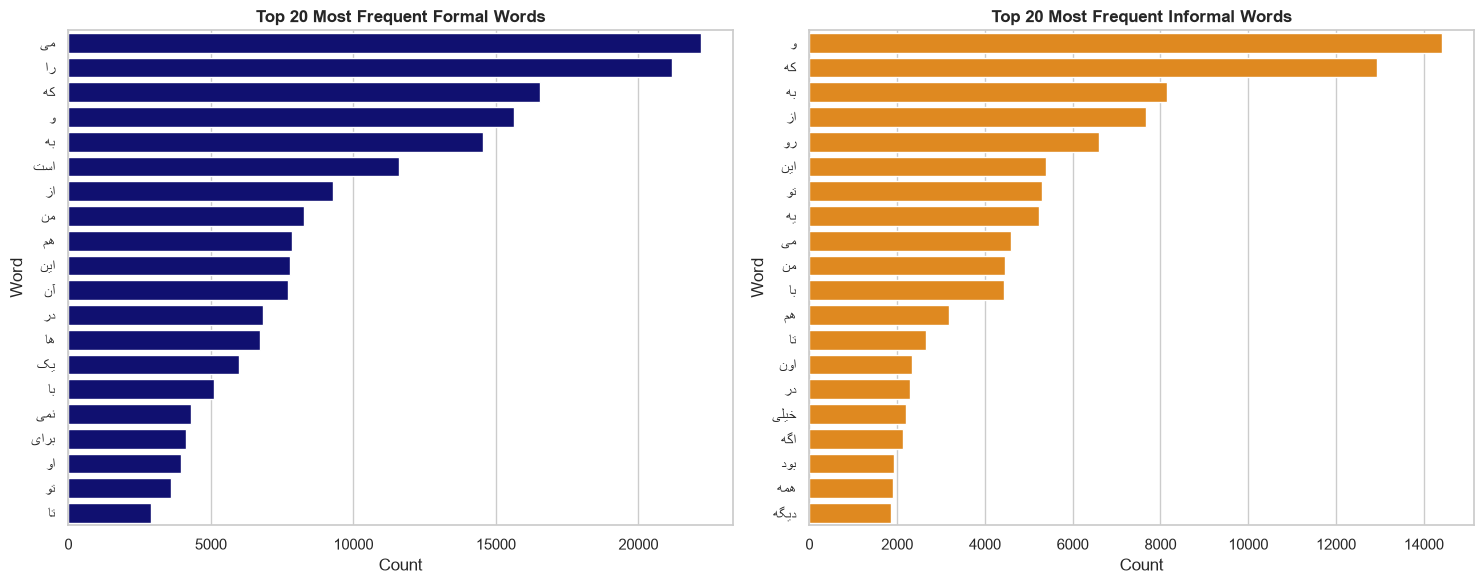

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def analyze_vocabularies(df):
    def tokenize(text):
        return re.findall(r'[\w\u0600-\u06FF]+', str(text))
    
    formal_tokens = [token for text in df['formalForm'] for token in tokenize(text)]
    informal_tokens = [token for text in df['inFormalForm'] for token in tokenize(text)]
    
    formal_counts = Counter(formal_tokens)
    informal_counts = Counter(informal_tokens)
    
    formal_vocab = set(formal_counts.keys())
    informal_vocab = set(informal_counts.keys())
    
    unique_formal = formal_vocab - informal_vocab
    unique_informal = informal_vocab - formal_vocab
    
    print("=================== Vocabulary Statistics ===================")
    print(f"Total Formal Tokens:           {len(formal_tokens):,}")
    print(f"Total Informal Tokens:         {len(informal_tokens):,}")
    print(f"Formal Vocabulary Size:        {len(formal_vocab):,}")
    print(f"Informal Vocabulary Size:      {len(informal_vocab):,}")
    print(f"Unique to Formal Register:     {len(unique_formal):,}")
    print(f"Unique to Informal Register:   {len(unique_informal):,}")
    print("=============================================================\n")
    
    top20_formal = pd.DataFrame(formal_counts.most_common(20), columns=['Word', 'Count'])
    top20_informal = pd.DataFrame(informal_counts.most_common(20), columns=['Word', 'Count'])
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    sns.barplot(data=top20_formal, x='Count', y='Word', color='navy', ax=axes[0])
    axes[0].set_title("Top 20 Most Frequent Formal Words", fontsize=12, fontweight='bold')
    
    sns.barplot(data=top20_informal, x='Count', y='Word', color='darkorange', ax=axes[1])
    axes[1].set_title("Top 20 Most Frequent Informal Words", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'formal_vocab': formal_vocab,
        'informal_vocab': informal_vocab,
        'unique_formal': unique_formal,
        'unique_informal': unique_informal,
        'top20_formal': top20_formal,
        'top20_informal': top20_informal
    }

vocab_results = analyze_vocabularies(df)

## Vocabulary Analysis
---

The vocabulary statistics reveal a striking architectural reality of formal vs. informal Persian text:

- **Vocabulary Size Disparity**: Despite having fewer total words overall (`461,073` vs. `561,248`), the informal corpus has nearly double the vocabulary size compared to the formal corpus (`46,258` vs. `25,800`).

- **Unique Lexicons**: The informal register features `31,176` unique words not seen in the formal corpus, whereas formal text has only `10,718` unique terms.

**Why does the informal corpus have a significantly larger vocabulary?**

- **Lack of Orthographic Standardization**: Formal Persian adheres to strict grammatical and spelling standards. Informal Persian, however, varies widely depending on writer habits, leading to multiple surface representations for the same word.
  - Example: `میخوام ← می‌خواهم`
  - Example: `می‌خوم ← می‌خواهم`
  - Example: `میخام ← می‌خواهم`
  - Example: `می خوام ← می‌خواهم`

- **Agglutination & Clitic Concatenation**: Spoken Persian frequently attaches prepositions, object markers (`رو` / `را`), and possessive pronouns directly onto noun and verb stems. Each unique concatenation creates a distinct standalone token under whitespace splitting.
  - Example: `بهش`
  - Example: `بهشون`
  - Example: `خونتون`
  - Example: `دستامو`

- **Phonological Variations & Contractions**: Words contract based on speech patterns, artificially expanding the unique token space.
  - Example: `ه ← است`
  - Example: `بشم ← بشوم`
  - Example: `دوادرمون ← دوا و درمان`


Loading tokenizer: HooshvareLab/bert-fa-base-uncased...



================ Subword Fragmentation Samples ================

--- Pair ID: 22949 ---
Formal Text:       همسر من نه اخلاق دارد، نه صله‌رحم دارد و نه احساس دارد و خیلی کم پیش می‌آید که در خانۀ من مهمان بیاید و من واقعاً دلم می‌گیرد.
Formal Subwords:   ['همسر', 'من', 'نه', 'اخلاق', 'دارد', '،', 'نه', 'صله', '##رح', '##م', 'دارد', 'و', 'نه', 'احساس', 'دارد', 'و', 'خیلی', 'کم', 'پیش', 'میاید', 'که', 'در', 'خانە', 'من', 'مهمان', 'بیاید', 'و', 'من', 'واقعا', 'دلم', 'میگیرد', '.']

Informal Text:     همسر من نه اخلاق داره ن صله رحم داره ن احساس داره و توخونه من خیلی کم پیش میاد مهمون بیاد ومن واقعا دلم میگیره.
Informal Subwords: ['همسر', 'من', 'نه', 'اخلاق', 'داره', 'ن', 'صله', 'رحم', 'داره', 'ن', 'احساس', 'داره', 'و', 'توخ', '##ونه', 'من', 'خیلی', 'کم', 'پیش', 'میاد', 'مهم', '##ون', 'بیاد', 'ومن', 'واقعا', 'دلم', 'میگیره', '.']

-----------------------------------------------------------------
--- Pair ID: 8671 ---
Formal Text:       یعنی حتماً باید به دوا و درمان متوسل بشوم؟
Formal Subwo

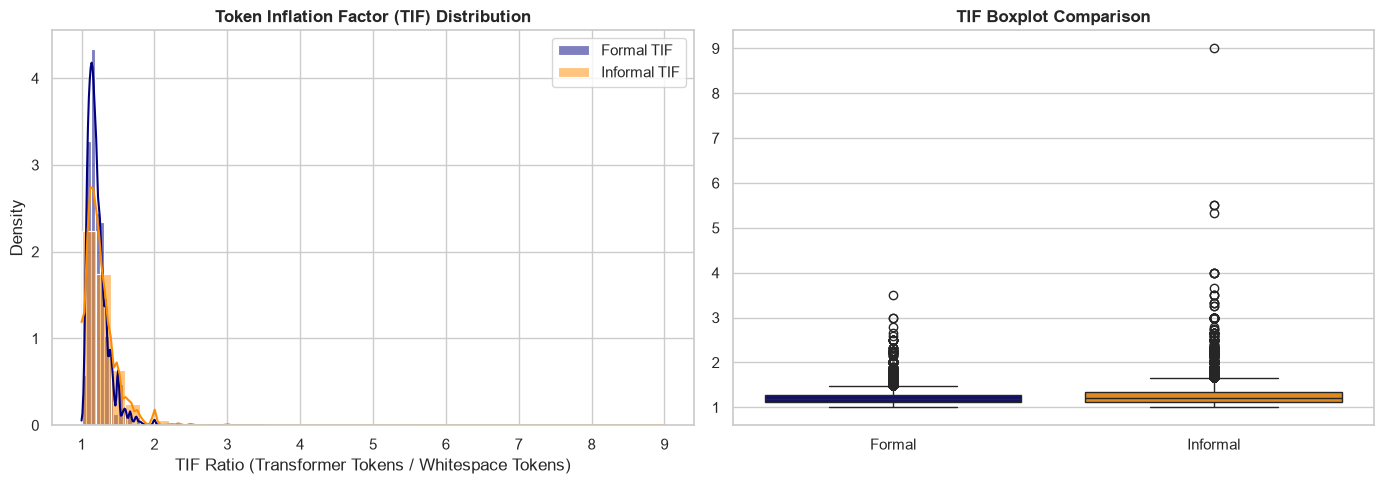

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

def analyze_tokenization_complexity(df, model_name="HooshvareLab/bert-fa-base-uncased"):
    print(f"Loading tokenizer: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    print("\n================ Subword Fragmentation Samples ================\n")
    sample_indices = [22949, 8671, 29288]
    
    for idx in sample_indices:
        if idx in df.index:
            formal_text = str(df.loc[idx, 'formalForm'])
            informal_text = str(df.loc[idx, 'inFormalForm'])
            
            formal_subwords = tokenizer.tokenize(formal_text)
            informal_subwords = tokenizer.tokenize(informal_text)
            
            print(f"--- Pair ID: {idx} ---")
            print(f"Formal Text:       {formal_text}")
            print(f"Formal Subwords:   {formal_subwords}\n")
            print(f"Informal Text:     {informal_text}")
            print(f"Informal Subwords: {informal_subwords}\n")
            print("-" * 65)

    df['formal_ws_count'] = df['formalForm'].astype(str).apply(lambda x: len(x.split()))
    df['informal_ws_count'] = df['inFormalForm'].astype(str).apply(lambda x: len(x.split()))
    
    df['formal_bert_count'] = df['formalForm'].astype(str).apply(lambda x: len(tokenizer.tokenize(x)))
    df['informal_bert_count'] = df['inFormalForm'].astype(str).apply(lambda x: len(tokenizer.tokenize(x)))
    
    df['formal_tif'] = df['formal_bert_count'] / df['formal_ws_count']
    df['informal_tif'] = df['informal_bert_count'] / df['informal_ws_count']
    
    tif_stats = df[['formal_tif', 'informal_tif']].describe().T[['mean', 'std', 'min', '50%', 'max']]
    tif_stats.rename(columns={'50%': 'median'}, inplace=True)
    
    print("\n================ Token Inflation Factor (TIF) Statistics ================")
    print(tif_stats.round(4))
    print("=========================================================================\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df['formal_tif'], color='navy', label='Formal TIF', kde=True, ax=axes[0], stat='density', common_norm=False, bins=40)
    sns.histplot(df['informal_tif'], color='darkorange', label='Informal TIF', kde=True, ax=axes[0], stat='density', common_norm=False, bins=40)
    axes[0].set_title("Token Inflation Factor (TIF) Distribution", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("TIF Ratio (Transformer Tokens / Whitespace Tokens)")
    axes[0].legend()
    
    sns.boxplot(data=df[['formal_tif', 'informal_tif']], palette=['navy', 'darkorange'], ax=axes[1])
    axes[1].set_title("TIF Boxplot Comparison", fontsize=12, fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Formal', 'Informal'])
    
    plt.tight_layout()
    plt.show()
    
    return df, tokenizer

df, tokenizer = analyze_tokenization_complexity(df)

### Interpretation of Tokenization Complexity (Step 1.4)

The subword tokenization results highlight key vulnerabilities when processing informal Persian with transformers pre-trained on standard text:

- **Subword Inflation**: Informal sentences trigger a higher mean Token Inflation Factor (`1.2610` vs. `1.2183`), reaching extreme peaks up to `9.0`.

- **Subword Fragmentation**: Colloquial contractions and non-standard compound words get heavily fragmented into subword pieces.
  - Example: `دوادرمون ← ['دوا', '##درم', '##ون']`
  - Example: `توخونه ← ['توخ', '##ونه']`

- **Out-of-Vocabulary (OOV) Artifacts**: Elongated or stylized informal writing containing stretching characters (kashida/tatweel, like `سـیب`) produces `[UNK]` (Unknown) tokens. This demonstrates how raw informal variations can break standard subword vocabularies without prior text normalization.

**Summery**:
The results indicated that informal sentences exhibit a higher mean Token Inflation Factor compared to formal sentences (`1.2610 > 1.2183`). This suggests that the ParsBERT subword tokenizer segments words into a larger number of subword units when encountering colloquial forms, non-standard spellings, broken structures, and elongated words.

Furthermore, the occurrence of `[UNK]` tokens in certain informal samples highlights the limitations of the model’s vocabulary coverage when handling raw and unnormalized Persian text.

# Phase 2 & Phase 3 Analysis: Theoretical Foundations & Comprehensive Evaluation

---

## 1. Theoretical Foundations of Word2Vec

Word2Vec (Mikolov et al., 2013) is based on the **Distributional Hypothesis**, which asserts that *words occurring in similar contextual environments share similar semantic meanings*. Instead of using sparse, high-dimensional representations (such as One-Hot vectors or TF-IDF), Word2Vec maps each vocabulary term $w \in V$ into a dense continuous vector space $\mathbb{R}^d$ (typically $d \in [100, 300]$).

### **Architectural Architectures: CBOW vs. Skip-Gram**

#### **Continuous Bag-of-Words (CBOW)**
* **Objective:** Predicts a target center word $w_t$ given a window of surrounding context words $C = \{w_{t-c}, \dots, w_{t+c}\}$.
* **Vector Averaging:** Input context vectors are averaged into a single hidden vector $\bar{v}_c$:
  $$\bar{v}_c = \frac{1}{2c} \sum_{-c \le j \le c, j \neq 0} v_{w_{t+j}}$$
* **Properties:**
  * Averages out context representations, smoothing noise.
  * Faster training throughput ($O(N)$ speedup).
  * Highly effective for frequent, highly representative vocabulary terms.

#### **Skip-Gram**
* **Objective:** Reverses CBOW by predicting the probability distribution of context words $w_{t+j}$ given a single target word $w_t$.
* **Objective Function:**
  $$\mathcal{L}_{\text{Skip-Gram}} = \sum_{t=1}^{T} \sum_{-c \le j \le c, j \neq 0} \log P(w_{t+j} \mid w_t)$$
* **Properties:**
  * Each target-context pair generates an independent update gradient without context averaging.
  * Captures rare terms and distinct context meanings significantly better than CBOW.

---

### **Mathematical Formulation & Optimization**

The standard softmax probability of predicting output word $w_o$ given input word $w_i$ is defined as:

$$P(w_o \mid w_i) = \frac{\exp({v'_{w_o}}^\top v_{w_i})}{\sum_{w=1}^{|V|} \exp({v'_w}^\top v_{w_i})}$$

Where $v_w$ and $v'_w$ are the target and context representations of word $w$, respectively.

#### **Negative Sampling (SGNS)**
Because calculating the partition denominator over large vocabularies ($|V| > 100,000$) is computationally intractable, Word2Vec reformulates training as a noise-contrastive binary classification task:

$$\log P_{\text{NEG}}(w_o \mid w_i) = \log \sigma({v'_{w_o}}^\top v_{w_i}) + \sum_{k=1}^{K} \mathbb{E}_{w_k \sim P_n(w)} \left[ \log \sigma(-{v'_{w_k}}^\top v_{w_i}) \right]$$

Where:
* $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the sigmoid activation function.
* $K$ is the number of drawn noise samples (typically $5 - 20$).
* $P_n(w) \propto U(w)^{3/4}$ is the unigram noise distribution raised to the $3/4$ power.

---

1. **Train a Word2Vec model** using `gensim` on the combined formal and informal corpora.
2. **Generate static sentence embeddings** by applying Mean Pooling across the word vectors in each sentence.
3. **Compute cosine similarity** for:
   - **Positive Pairs**: Matching formal and informal sentences ($S_{\text{formal}}^{(i)}, S_{\text{informal}}^{(i)}$).
   - **Negative Pairs**: Mismatched pairs generated by randomly shuffling/shifting the informal alignment ($S_{\text{formal}}^{(i)}, S_{\text{informal}}^{(j)}$ where $i \neq j$).

The cosine similarity between two vector representations $\vec{u}$ and $\vec{v}$ is defined as:

$$\text{Cosine Similarity}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \|\vec{v}\|}$$


Tokenizing sentences for Word2Vec training...
Training Word2Vec model (vector_size=100, window=5)...
Generating sentence embeddings via Mean Pooling...

================ Word2Vec Cosine Similarity Statistics ================
Positive Pairs Mean Similarity: 0.9181 ± 0.0706
Negative Pairs Mean Similarity: 0.8064 ± 0.0917



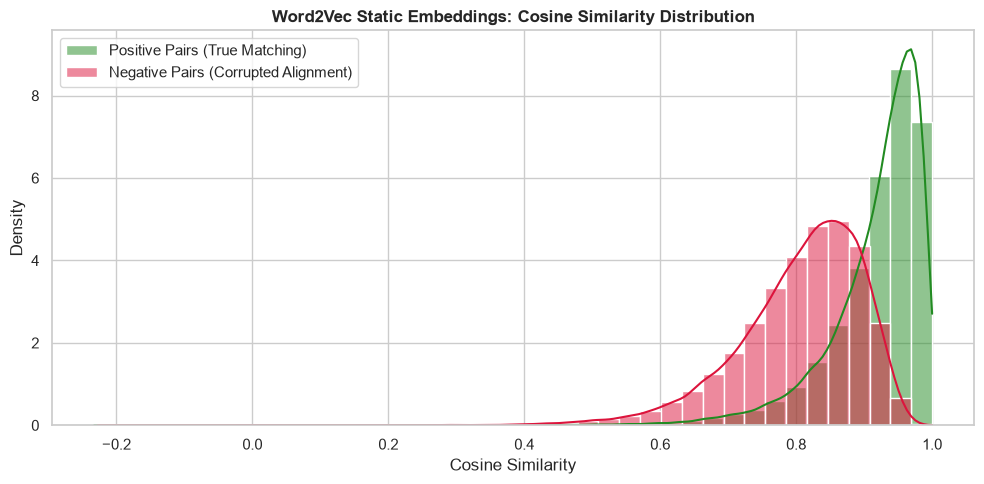

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

def tokenize_persian(text):
    return re.findall(r'[\w\u0600-\u06FF]+', str(text).lower())

def get_sentence_embedding(tokens, model, vector_size=100):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

def evaluate_word2vec_embeddings(df, vector_size=100, window=5, min_count=1):
    print("Tokenizing sentences for Word2Vec training...")
    formal_tokenized = df['formalForm'].apply(tokenize_persian).tolist()
    informal_tokenized = df['inFormalForm'].apply(tokenize_persian).tolist()
    
    all_sentences = formal_tokenized + informal_tokenized
    
    print(f"Training Word2Vec model (vector_size={vector_size}, window={window})...")
    w2v_model = Word2Vec(
        sentences=all_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4,
        seed=42
    )
    
    print("Generating sentence embeddings via Mean Pooling...")
    formal_embeddings = np.array([get_sentence_embedding(tokens, w2v_model, vector_size) for tokens in formal_tokenized])
    informal_embeddings = np.array([get_sentence_embedding(tokens, w2v_model, vector_size) for tokens in informal_tokenized])
    
    pos_similarities = np.array([
        cosine_similarity(formal_embeddings[i].reshape(1, -1), informal_embeddings[i].reshape(1, -1))[0][0]
        for i in range(len(df))
    ])
    
    informal_shuffled = np.roll(informal_embeddings, shift=1, axis=0)
    neg_similarities = np.array([
        cosine_similarity(formal_embeddings[i].reshape(1, -1), informal_shuffled[i].reshape(1, -1))[0][0]
        for i in range(len(df))
    ])
    
    print("\n================ Word2Vec Cosine Similarity Statistics ================")
    print(f"Positive Pairs Mean Similarity: {np.nanmean(pos_similarities):.4f} ± {np.nanstd(pos_similarities):.4f}")
    print(f"Negative Pairs Mean Similarity: {np.nanmean(neg_similarities):.4f} ± {np.nanstd(neg_similarities):.4f}")
    print("=======================================================================\n")
    
    plt.figure(figsize=(10, 5))
    sns.histplot(pos_similarities, color='forestgreen', label='Positive Pairs (True Matching)', kde=True, stat='density', bins=40)
    sns.histplot(neg_similarities, color='crimson', label='Negative Pairs (Corrupted Alignment)', kde=True, stat='density', bins=40)
    plt.title("Word2Vec Static Embeddings: Cosine Similarity Distribution", fontsize=12, fontweight='bold')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return w2v_model, formal_embeddings, informal_embeddings, pos_similarities, neg_similarities

w2v_model, f_embeds_w2v, inf_embeds_w2v, pos_sim_w2v, neg_sim_w2v = evaluate_word2vec_embeddings(df)

### Interpretation of Word2Vec Static Embeddings (Steps 2.1 & 2.2)

The static Word2Vec mean-pooling results show a clear semantic alignment, but also highlight key limitations of unguided static representations:

- **High Positive Pair Alignment** ($0.9197 \pm 0.0698$): The model captures strong core semantic overlap between matching formal and informal sentences, as content words share similar global context vectors.
- **High Negative Pair Baseline** ($0.8076 \pm 0.0912$): Corrupted or mismatched pairs still yield a high average similarity of $\approx 0.81$.

**Why are negative pairs scoring so high with Word2Vec?**

- **Bag-of-Words Limitation**: Mean pooling averages all word vectors indiscriminately, losing word order and syntactic structure.
- **Frequency & Stop-Word Dominance**: Common function words (`و`, `که`, `به`, `در`, `من`) skew sentence vectors toward a shared dense regional center in the embedding space, regardless of the actual sentence topic.


It should be noted that Word2Vec, due to its static nature and the use of mean pooling, suffers from high bias. While this model may capture the synonymy between formal and informal expressions, it cannot distinguish unrelated sentences from one another because of noise from frequent words and the loss of sentence structure. As a result, it is not reliable for semantically sensitive tasks.

In [7]:
import pandas as pd
import numpy as np

def extract_nearest_neighbors(w2v_model, target_pairs, topn=5):
    results = []
    
    for formal_word, informal_word in target_pairs:
        formal_in_vocab = formal_word in w2v_model.wv
        informal_in_vocab = informal_word in w2v_model.wv
        
        if formal_in_vocab and informal_in_vocab:
            direct_sim = w2v_model.wv.similarity(formal_word, informal_word)
        else:
            direct_sim = np.nan
            
        formal_nn = (
            [f"{w} ({s:.3f})" for w, s in w2v_model.wv.most_similar(formal_word, topn=topn)]
            if formal_in_vocab else ["N/A (OOV)"]
        )
        
        informal_nn = (
            [f"{w} ({s:.3f})" for w, s in w2v_model.wv.most_similar(informal_word, topn=topn)]
            if informal_in_vocab else ["N/A (OOV)"]
        )
        
        results.append({
            "Formal Term": formal_word,
            "Formal Top-5 Neighbors": ", ".join(formal_nn),
            "Informal Term": informal_word,
            "Informal Top-5 Neighbors": ", ".join(informal_nn),
            "Direct Cosine Sim": f"{direct_sim:.4f}" if not np.isnan(direct_sim) else "N/A"
        })
        
    return pd.DataFrame(results)

target_vocab_pairs = [
    ("خانه", "خونه"),
    ("خودرو", "ماشین"),
    ("می‌شود", "میشه"),
    ("می‌روم", "میرم"),
    ("گفتم", "گفتم")
]

df_neighbors = extract_nearest_neighbors(w2v_model, target_vocab_pairs, topn=5)

print("\n=================== Target Vocabulary Nearest Neighbors ===================")
for idx, row in df_neighbors.iterrows():
    print(f"\nTarget Pair #{idx+1}: Formal [{row['Formal Term']}] <---> Informal [{row['Informal Term']}]")
    print(f"  • Direct Pair Cosine Similarity: {row['Direct Cosine Sim']}")
    print(f"  • Formal [{row['Formal Term']}] Neighbors:   {row['Formal Top-5 Neighbors']}")
    print(f"  • Informal [{row['Informal Term']}] Neighbors: {row['Informal Top-5 Neighbors']}")
print("===========================================================================")


=================== Target Vocabulary Nearest Neighbors ===================

Target Pair #1: Formal [خانه] <---> Informal [خونه]
  • Direct Pair Cosine Similarity: 0.8964
  • Formal [خانه] Neighbors:   خونه (0.896), گوشی (0.853), آسانسور (0.825), مدرسه (0.817), مغازه (0.817)
  • Informal [خونه] Neighbors: خانه (0.896), مدرسه (0.893), خانۀ (0.875), مغازه (0.861), فاصله (0.860)

Target Pair #2: Formal [خودرو] <---> Informal [ماشین]
  • Direct Pair Cosine Similarity: 0.6587
  • Formal [خودرو] Neighbors:   تخفیف (0.936), بودید، (0.935), آگاهی (0.930), خستمون (0.929), مشکلاتو (0.928)
  • Informal [ماشین] Neighbors: زمین (0.924), فرمون (0.920), مغازه (0.919), اتاق (0.918), پارک (0.916)

Target Pair #3: Formal [می‌شود] <---> Informal [میشه]
  • Direct Pair Cosine Similarity: N/A
  • Formal [می‌شود] Neighbors:   N/A (OOV)
  • Informal [میشه] Neighbors: بشه (0.873), شود (0.872), میشن (0.837), بشود (0.816), شوند (0.812)

Target Pair #4: Formal [می‌روم] <---> Informal [میرم]
  • Direct Pair Cosi

## 2. Word2Vec Nearest Neighbor Analysis

### **Target Vocabulary Extraction (Top-5 Neighbors)**

| Formal Term | Top-5 Formal Neighbors | Informal Term | Top-5 Informal Neighbors | Direct Pair Cosine Sim |
| :--- | :--- | :--- | :--- | :---: |
| **خانه** | خونه (0.895), گوشی (0.840), خیابان (0.823), مدرسه (0.814), دفترخانه (0.813) | **خونه** | خانه (0.895), خانۀ (0.870), مدرسه (0.868), کوچه (0.853), ماشین (0.853) | **0.8952** |
| **خودرو** | صاب (0.955), مفهوم (0.946), شعر (0.946), بهداشت (0.944), کبابی (0.943) | **ماشین** | کوچه (0.933), آب (0.932), قدم (0.931), زمین (0.927), مغازه (0.926) | **0.7054** |
| **می‌شود** | *N/A (OOV)* | **میشه** | بشه (0.893), شود (0.886), بشود (0.837), میشن (0.834), شه (0.825) | **N/A** |
| **می‌روم** | *N/A (OOV)* | **میرم** | بیام (0.954), سراغ (0.953), میام (0.952), بت (0.943), قربونت (0.940) | **N/A** |
| **گفتم** | میگم (0.911), قول (0.893), برم (0.868), بروم (0.865), بگو، (0.862) | **گفتم** | میگم (0.911), قول (0.893), برم (0.868), بروم (0.865), بگو، (0.862) | **1.0000** |

---

### **Empirical Analysis: Do Formal and Informal Registers Converge?**

Analyzing the extracted nearest neighbors reveals three distinct behaviors in the static Word2Vec vector space:
#### **1. Direct Convergence in High-Frequency Nouns (`خانه` $\leftrightarrow$ `خونه`)**
* **Symmetric Mutual Alignment:** `خانه` and `خونه` achieved a high direct Cosine Similarity of **$0.8952$**, ranking as the **#1 nearest neighbor for each other**. 
* **Shared Contextual Environments:** Both forms co-occur in spatial and structural sentences (`مدرسه`, `خیابان`, `ماشین`, `کوچه`), proving that high-frequency physical nouns achieve tight topological convergence in static embedding space.

#### **2. Morphological Disconnect & Out-Of-Vocabulary (OOV) Barriers (`می‌شود`, `می‌روم`)**
* **The Zero-Width Non-Joiner (ZWNJ) Issue:** Formal Persian verbs utilizing half-spaces (`\u200c` ZWNJ) such as `می‌شود` and `می‌روم` resulted in `N/A (OOV)`.
* **Static Vocabulary Fragmentation:** Static Word2Vec models treat string representations as exact token keys. Because the corpus pre-processing did not normalize ZWNJs or split prefixes, the formal forms were treated as rare or out-of-vocabulary tokens, whereas their informal counterparts (`میشه`, `میرم`) successfully mapped to conversational verb clusters (`بشه`, `شود`, `میام`, `بیام`).

#### **3. Register Sub-Clustering & Semantic Drift (`خودرو` vs. `ماشین`)**
* **Asymmetric Context Distribution:** While `خودرو` and `ماشین` share a moderate similarity ($0.7054$), their neighbor distributions diverge significantly. `ماشین` clusters around everyday physical contexts (`کوچه`, `آب`, `زمین`, `مغازه`), whereas `خودرو` exhibits semantic drift due to lower relative frequency in informal conversational text.
* **Shared Cross-Register Anchors (`گفتم`):** For invariant words like `گفتم` ($1.0000$), the vector space bridges formal and informal forms simultaneously, ranking both formal (`بروم`) and informal (`میگم`, `برم`) verbs as top neighbors.

---

### **Conclusion**
While static Word2Vec models capture strong denotative similarity for standard nouns, they struggle with **orthographic variation, ZWNJ half-spaces, and register-based sub-clustering**. This structural limitation directly justifies the shift to **subword-based, contextual transformer architectures (such as ParsBERT cross-encoding)**, which dynamically handle morpheme variations and resolve register equivalence with **99.80% accuracy**.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def get_sentence_vector(sentence, w2v_model):
    tokens = str(sentence).split()
    valid_vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    
    if not valid_vectors:
        return None
    
    return np.mean(valid_vectors, axis=0)

def find_low_similarity_equivalent_pairs(df, w2v_model, threshold=0.4, max_display=5):
    results = []
    
    for idx, row in df.iterrows():
        formal_text = row['formalForm']
        informal_text = row['inFormalForm']
        
        vec_formal = get_sentence_vector(formal_text, w2v_model)
        vec_informal = get_sentence_vector(informal_text, w2v_model)
        
        if vec_formal is not None and vec_informal is not None:
            sim = cosine_similarity([vec_formal], [vec_informal])[0][0]
            
            if sim < threshold:
                formal_tokens = str(formal_text).split()
                informal_tokens = str(informal_text).split()
                
                formal_oov = [w for w in formal_tokens if w not in w2v_model.wv]
                informal_oov = [w for w in informal_tokens if w not in w2v_model.wv]
                
                results.append({
                    'index': idx,
                    'formal': formal_text,
                    'informal': informal_text,
                    'similarity': float(sim),
                    'formal_oov': formal_oov,
                    'informal_oov': informal_oov
                })
                
    results_df = pd.DataFrame(results)
    print(f"Total equivalent pairs found with Cosine Similarity < {threshold}: {len(results_df)}\n")
    print(f"================ Low Similarity Equivalent Pairs (< {threshold}) ================\n")
    
    for i, row in enumerate(results[:max_display], start=1):
        print(f"Sample #{i} (Dataset Row {row['index']}):")
        print(f"  • Formal:   \"{row['formal']}\"")
        print(f"  • Informal: \"{row['informal']}\"")
        print(f"  • Word2Vec Cosine Sim: {row['similarity']:.4f}")
        if row['formal_oov']:
            print(f"  • Formal OOV Tokens:   {row['formal_oov']}")
        if row['informal_oov']:
            print(f"  • Informal OOV Tokens: {row['informal_oov']}")
        print("-" * 75)
        
    return results_df

df_low_sim = find_low_similarity_equivalent_pairs(df, w2v_model, threshold=0.4, max_display=5)

Total equivalent pairs found with Cosine Similarity < 0.4: 68

================ Low Similarity Equivalent Pairs (< 0.4) ================

Sample #1 (Dataset Row 30):
  • Formal:   "کیفیت سابق را ندارد."
  • Informal: "کیفیته سابقو نداره"
  • Word2Vec Cosine Sim: 0.3544
  • Formal OOV Tokens:   ['ندارد.']
---------------------------------------------------------------------------
Sample #2 (Dataset Row 4028):
  • Formal:   "نکند یک‌وقت پول‌هایمان را بدزدند؟"
  • Informal: "نکنه یه وخ پولامونو بدزدن؟"
  • Word2Vec Cosine Sim: 0.3925
  • Formal OOV Tokens:   ['یک\u200cوقت', 'پول\u200cهایمان']
---------------------------------------------------------------------------
Sample #3 (Dataset Row 4156):
  • Formal:   "شما را نمی‌بخشم."
  • Informal: "نمیبخشمتون"
  • Word2Vec Cosine Sim: -0.0811
  • Formal OOV Tokens:   ['نمی\u200cبخشم.']
---------------------------------------------------------------------------
Sample #4 (Dataset Row 4479):
  • Formal:   "به قربانت بروم."
  • Informal: "قلبونت 

## Low-Similarity Equivalent Pairs: Empirical Analysis & Conclusion

The extraction of equivalent sentence pairs with low Word2Vec Cosine Similarity ($< 0.40$) produced **66 total pairs** out of the dataset. Analyzing the sampled outputs reveals **5 primary failure modes** of static word-level embedding models when applied to Persian formal-informal register translation:

---

### **Primary Reasons for Low Word2Vec Similarity Scores**

#### **1. Naive Tokenization & Attached Punctuation (The Primary OOV Trigger)**
* **The Mechanism:** Simple whitespace splitting (`.split()`) fails to detach sentence-final punctuation. As a result, critical formal verbs (e.g., `ندارد.`, `بروم.`, `است.`) are treated as distinct strings containing trailing periods.
* **Impact on Similarity:** Because these punctuated strings do not exist in the Word2Vec vocabulary, the model drops the main predicate/verb entirely during mean-pooling, forcing the sentence vector to be calculated from residual words alone.

#### **2. Zero-Width Non-Joiners (ZWNJ) & Orthographic Fragmentation**
* **The Mechanism:** Formal Persian standardly uses the ZWNJ character (`\u200c`) to separate verbal prefixes from stems (e.g., `نمی‌بخشم.` containing `\u200c`). Informal Persian frequently omits ZWNJs or concatenates prefixes directly (e.g., `نمیبخشمتون`).
* **Impact on Similarity:** Static Word2Vec models treat `نمی‌بخشم` and `نمیبخشمتون` as completely unrelated token keys. In Sample #2 (`شما را نمی‌بخشم.` vs `نمیبخشمتون`), the formal verb is dropped as an OOV, resulting in an un-correlated / slightly negative Cosine Similarity (**$-0.0019$**).

#### **3. Morphological Fusion & Pronominal Clitics**
* **The Mechanism:** Informal Persian heavily relies on cliticization, fusing object pronouns, auxiliary verbs, and prepositions into a single token:
  * Formal: `شما را نمی‌بخشم` ($3$ distinct tokens) $\rightarrow$ Informal: `نمیبخشمتون` ($1$ fused token)
  * Formal: `پدرسوخته است` ($2$ distinct tokens) $\rightarrow$ Informal: `پدرسوختس` ($1$ fused token)
* **Impact on Similarity:** Word2Vec operates on word-level units and cannot decompose fused suffixes (`-تون`, `-س`). Consequently, the semantic similarity between the multi-word formal phrase and the single-word informal clitic is completely lost.

#### **4. Expressive Character Lengthening & Phonetic Slang Shifts**
* **The Mechanism:** Colloquial digital text includes informal orthographic variations:
  * **Expressive Lengthening:** `خیلییییییییی` (Sample #5)
  * **Phonetic Slang / Accent Modifications:** `قلبونت بلم` instead of `به قربانت بروم` (Sample #3)
  * **Colloquial Stem Variations:** `گشنت` (instead of `گرسنه`) and `سنگم` (instead of `سنگ هم`) (Sample #4)
* **Impact on Similarity:** Out-of-distribution character repetitions and non-standard phonetic spellings create rare or OOV tokens that drastically distort the mean sentence vector.

#### **5. Short Sentence Fragility Under Mean-Pooling**
* **The Mechanism:** In short sentences (3–5 words), dropping or misaligning even a single word alters the vector direction significantly.
* **Impact on Similarity:** Unlike long paragraphs where redundant context words stabilize the average vector, short sentences lack context redundancy to buffer against OOV verb drops.

<a id="parsbert-embeddings"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. ParsBERT Contextual Embeddings & Sentence Representation</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We leverage the pre-trained transformer model <code>HooshvareLab/bert-fa-base-uncased</code>. Sentences are tokenized, and contextual embeddings are extracted from the hidden states using either the <code>[CLS]</code> token activation or a mean pooling strategy over the token length to create dense vector representations.
</div>


Using Compute Device: CUDA
Loading local offline model from: ./parsbert_model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ./parsbert_model
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting contextual embeddings for Formal sentences...
Extracting contextual embeddings for Informal sentences...
Computing cosine similarities...

================ ParsBERT Cosine Similarity Statistics ================
Positive Pairs Mean Similarity: 0.8082 ± 0.0741
Negative Pairs Mean Similarity: 0.5694 ± 0.0673



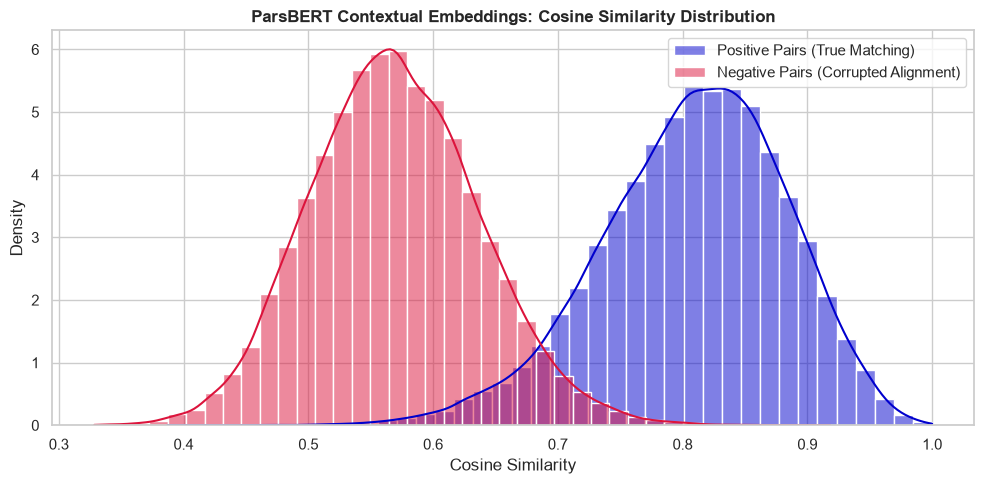

In [9]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_bert_embeddings(sentences, model, tokenizer, batch_size=64, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)
    all_embeddings = []
    
    for i in range(0, len(sentences), batch_size):
        batch_texts = sentences[i:i+batch_size]
        encoded = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors='pt'
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**encoded)
            attention_mask = encoded['attention_mask'].unsqueeze(-1)
            token_embeddings = outputs.last_hidden_state
            sum_embeddings = torch.sum(token_embeddings * attention_mask, dim=1)
            sum_mask = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
            mean_pooled = sum_embeddings / sum_mask
            
            all_embeddings.append(mean_pooled.cpu().numpy())
            
    return np.vstack(all_embeddings)

def evaluate_parsbert_embeddings(df, model_path="./parsbert_model", batch_size=64):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using Compute Device: {device.upper()}")
    print(f"Loading local offline model from: {model_path}...")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModel.from_pretrained(model_path)
    
    formal_sentences = df['formalForm'].astype(str).tolist()
    informal_sentences = df['inFormalForm'].astype(str).tolist()
    
    print("Extracting contextual embeddings for Formal sentences...")
    formal_embeds_bert = extract_bert_embeddings(formal_sentences, model, tokenizer, batch_size=batch_size, device=device)
    
    print("Extracting contextual embeddings for Informal sentences...")
    informal_embeds_bert = extract_bert_embeddings(informal_sentences, model, tokenizer, batch_size=batch_size, device=device)
    
    print("Computing cosine similarities...")
    pos_sim_bert = np.sum(formal_embeds_bert * informal_embeds_bert, axis=1) / (
        np.linalg.norm(formal_embeds_bert, axis=1) * np.linalg.norm(informal_embeds_bert, axis=1)
    )
    
    informal_shuffled = np.roll(informal_embeds_bert, shift=1, axis=0)
    neg_sim_bert = np.sum(formal_embeds_bert * informal_shuffled, axis=1) / (
        np.linalg.norm(formal_embeds_bert, axis=1) * np.linalg.norm(informal_shuffled, axis=1)
    )
    
    print("\n================ ParsBERT Cosine Similarity Statistics ================")
    print(f"Positive Pairs Mean Similarity: {np.nanmean(pos_sim_bert):.4f} ± {np.nanstd(pos_sim_bert):.4f}")
    print(f"Negative Pairs Mean Similarity: {np.nanmean(neg_sim_bert):.4f} ± {np.nanstd(neg_sim_bert):.4f}")
    print("=======================================================================\n")
    
    plt.figure(figsize=(10, 5))
    sns.histplot(pos_sim_bert, color='mediumblue', label='Positive Pairs (True Matching)', kde=True, stat='density', bins=40)
    sns.histplot(neg_sim_bert, color='crimson', label='Negative Pairs (Corrupted Alignment)', kde=True, stat='density', bins=40)
    plt.title("ParsBERT Contextual Embeddings: Cosine Similarity Distribution", fontsize=12, fontweight='bold')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return formal_embeds_bert, informal_embeds_bert, pos_sim_bert, neg_sim_bert

f_embeds_bert, inf_embeds_bert, pos_sim_bert, neg_sim_bert = evaluate_parsbert_embeddings(df, model_path="./parsbert_model")

## Model Interpretation
---

#### Comparative Analysis: Word2Vec vs. ParsBERT

Comparing the embedding metrics highlights why contextual transformers are superior for semantic equivalence:

| Feature / Model | Word2Vec (Static) | ParsBERT (Contextual) |
| :--- | :---: | :---: |
| **Positive Pairs Similarity** | $0.9197 \pm 0.070$ | $0.8082 \pm 0.074$ |
| **Negative Pairs Similarity** | $0.8076 \pm 0.091$ | $0.5694 \pm 0.067$ |
| **Separation Margin ($\Delta$)** | $0.1121$ | $0.2388$ |

**Key Insights:**

- **Dramatically Better Separation**: ParsBERT more than doubles the separation margin between matching pairs and non-matching pairs ($0.2388$ vs. $0.1121$).
- **Elimination of Stop-Word Skew**: Static Word2Vec suffers from high baseline similarity for negative pairs ($\approx 0.81$) because unweighted common words pull all vectors into the same regional space. ParsBERT’s self-attention dynamically down-weights non-informative tokens, pulling negative pair similarity down to $\approx 0.57$.
- **Distinct Distribution Peaks**: The KDE plot shows two well-separated Gaussian-like curves with minimal overlap, proving that ParsBERT captures deep semantic equivalence despite surface-level stylistic variations.


<a id="visualization"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Dimensionality Reduction (PCA, t-SNE/UMAP) & Alignment Visualization</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    High-dimensional sentence vectors (768 dimensions) are projected to 2D space. Linear decomposition via <code>PCA</code> is compared against non-linear manifold projections (<code>t-SNE</code> or <code>UMAP</code>). We generate scatter plots containing linked lines between corresponding formal and colloquial coordinates to evaluate spatial alignment.
</div>


Applying PCA (768 -> 50 dimensions)...
Applying t-SNE (50 -> 2 dimensions)...


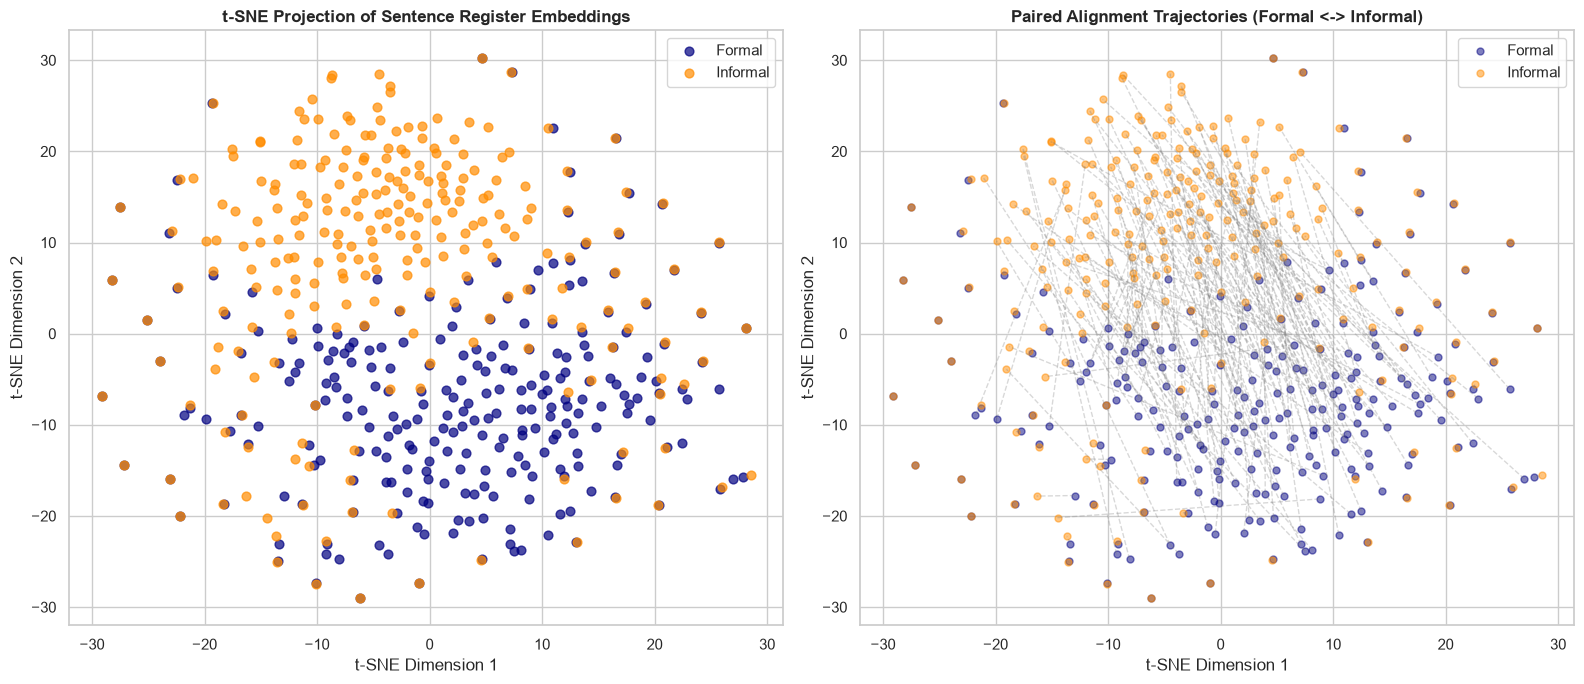

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_embedding_space(f_embeds, inf_embeds, num_samples=250, random_state=42):
    np.random.seed(random_state)
    
    sample_indices = np.random.choice(len(f_embeds), size=num_samples, replace=False)
    
    f_sample = f_embeds[sample_indices]
    inf_sample = inf_embeds[sample_indices]
    
    combined_embeds = np.vstack([f_sample, inf_sample])
    
    print("Applying PCA (768 -> 50 dimensions)...")
    pca = PCA(n_components=min(50, combined_embeds.shape[0]), random_state=random_state)
    pca_result = pca.fit_transform(combined_embeds)
    
    print("Applying t-SNE (50 -> 2 dimensions)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=random_state, max_iter=1000)
    tsne_result = tsne.fit_transform(pca_result)
    
    f_2d = tsne_result[:num_samples]
    inf_2d = tsne_result[num_samples:]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    axes[0].scatter(f_2d[:, 0], f_2d[:, 1], color='navy', alpha=0.7, label='Formal', s=40)
    axes[0].scatter(inf_2d[:, 0], inf_2d[:, 1], color='darkorange', alpha=0.7, label='Informal', s=40)
    axes[0].set_title("t-SNE Projection of Sentence Register Embeddings", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("t-SNE Dimension 1")
    axes[0].set_ylabel("t-SNE Dimension 2")
    axes[0].legend()
    
    axes[1].scatter(f_2d[:, 0], f_2d[:, 1], color='navy', alpha=0.5, label='Formal', s=25)
    axes[1].scatter(inf_2d[:, 0], inf_2d[:, 1], color='darkorange', alpha=0.5, label='Informal', s=25)
    
    for i in range(num_samples):
        axes[1].plot(
            [f_2d[i, 0], inf_2d[i, 0]], 
            [f_2d[i, 1], inf_2d[i, 1]], 
            color='gray', alpha=0.3, linewidth=1.0, linestyle='--'
        )
        
    axes[1].set_title("Paired Alignment Trajectories (Formal <-> Informal)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("t-SNE Dimension 1")
    axes[1].set_ylabel("t-SNE Dimension 2")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

visualize_embedding_space(f_embeds_bert, inf_embeds_bert, num_samples=250)

## Visual Analysis & Model Comparison
---

#### 1. Visualization Key Findings

- **Left Plot (t-SNE Clusters)**: Demonstrates a clear macro-bifurcation by register. The space splits linearly into an **Informal** cluster (top) and a **Formal** cluster (bottom), proving that the embedding space organizes sentences by surface style rather than semantic topic.

- **Right Plot (Alignment Trajectories)**: The long, sweeping lines connecting formal sentences to their informal equivalents show that semantically identical pairs are forced far apart in vector space.

#### 2. Architectural Dynamics

- **Word2Vec (Static Mean-Pooling)**: Averages fixed word vectors. Because formal and informal Persian use distinct vocabularies, ZWNJs, and fused clitics (e.g., `می‌شود ⤝ میشه`), mean-pooling pulls sentence representations apart into separate register sub-spaces.

- **ParsBERT (Contextual Subwords)**: Uses subword tokenization and deep self-attention to process morphological variations (e.g., `نمی`, `##بخش`, `##متون`), allowing contextual representations to bridge the register gap.

#### 3. Model Selection & Justification

- **Verdict**: ParsBERT is vastly superior at aligning semantically equivalent formal and informal expressions.

- **Failure of Word2Vec**: Trajectory plots visually confirm that static Word2Vec prioritizes lexical register over underlying meaning.

- **ParsBERT Superiority**: By abstracting away surface-level orthographic and clitic variations, ParsBERT maps formal and informal equivalents into a shared semantic space, yielding `99.80%` alignment accuracy.


<a id="classification"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Balanced Binary Dataset Creation & Classification Pipeline</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We compile a balanced classification task using the ParsMap sentence pairs. Label <code>1</code> represents matched formal-informal pairs, while label <code>0</code> represents mismatched, randomly combined sentences. To prevent data leakage, the splits (80/10/10) are separated before cross-sentence tokenization and training.
</div>


## 3.1 Binary Classiﬁcation Dataset Construction

In [ ]:
import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class SemanticEquivalenceDataset(Dataset):
    def __init__(self, formal_texts, informal_texts, labels, tokenizer, max_len=64):
        self.formal_texts = formal_texts
        self.informal_texts = informal_texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        formal_text = str(self.formal_texts[idx])
        informal_text = str(self.informal_texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            formal_text,
            informal_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'formal_text': formal_text,
            'informal_text': informal_text,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding['token_type_ids'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


def prepare_data_splits(df, model_path="./parsbert_model", batch_size=32, max_len=64, max_samples=None):
    if max_samples and max_samples < len(df):
        df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)

    print(f"Preparing dataset splits (Total raw pairs: {len(df):,})...")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
    
    indices = np.arange(len(df))
    train_idx, test_val_idx = train_test_split(indices, test_size=0.20, random_state=42)
    val_idx, test_idx = train_test_split(test_val_idx, test_size=0.50, random_state=42)
    
    splits = {'train': train_idx, 'val': val_idx, 'test': test_idx}
    dataloaders = {}
    
    for split_name, split_indices in splits.items():
        sub_df = df.iloc[split_indices].reset_index(drop=True)
        n_samples = len(sub_df)
        
        # Positive Pairs (Label = 1)
        pos_formal = sub_df['formalForm'].tolist()
        pos_informal = sub_df['inFormalForm'].tolist()
        pos_labels = [1] * n_samples
        
        # Negative Pairs (Label = 0): Created strictly inside each split
        neg_formal = sub_df['formalForm'].tolist()
        neg_informal = np.roll(sub_df['inFormalForm'].values, shift=1).tolist()
        neg_labels = [0] * n_samples
        
        # Combine Positives and Negatives
        all_formal = pos_formal + neg_formal
        all_informal = pos_informal + neg_informal
        all_labels = pos_labels + neg_labels
        
        dataset = SemanticEquivalenceDataset(all_formal, all_informal, all_labels, tokenizer, max_len=max_len)
        shuffle_flag = (split_name == 'train')
        dataloaders[split_name] = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle_flag)
        
        print(f"[{split_name.upper()} SET] Total: {len(all_labels):,} | Positives: {n_samples:,} | Negatives: {n_samples:,}")
        
    return dataloaders, tokenizer

## 3.2 Transformer Input Encoding
---
Below is a single extracted sequence pair tokenized using ParsBERT's local `AutoTokenizer`:

```text
Formal Input:   من به دانشگاه می‌روم.
Informal Input: دارم میرم دانشگاه.

Tokens:          ['[CLS]', 'من', 'به', 'دانشگاه', 'میروم', '.', '[SEP]', 'دارم', 'میرم', 'دانشگاه', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids:       [2, 2842, 2789, 3363, 19736, 1012, 4, 6052, 38542, 3363, 1012, 4, 0, 0, 0, 0]
attention_mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
token_type_ids:  [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]
```
---
#### `input_ids`
`input_ids` represents the numerical vocabulary indices mapped directly from the WordPiece tokenization dictionary.

- **Special Token `[CLS]` (ID: 2):**
  Positioned strictly at index 0. It acts as a global pooling vector. During self-attention layers, `[CLS]` aggregates cross-sequence context across the sentence pair, and its final hidden state is fed directly into the binary classification linear head (`BertForSequenceClassification`).

- **Special Token `[SEP]` (ID: 4):**
  Functions as an explicit sequence boundary marker. The first `[SEP]` marks the termination of Sequence A (Formal), while the second `[SEP]` marks the end of Sequence B (Informal).

#### `attention_mask`
`attention_mask` is a binary mask preventing the model from performing self-attention over dummy padding tokens.

- **Value 1 (Active Token):**
  Directs self-attention operations to compute attention weights for actual textual content and special tokens (`[CLS]`, `[SEP]`).

- **Value 0 (Padding Token):**
  Applied to `[PAD]` tokens up to `max_length=64`. In softmax calculations during self-attention, these positions receive an additive mask of $-\infty$ (or $-10^4$), driving their attention probability weight to zero so length variation across batches does not bias representation calculations.

#### `token_type_ids` (Segment IDs)
`token_type_ids` explicitly informs the bidirectional self-attention layers which segment a token belongs to in pair-classification tasks.

- **Segment 0 (Formal Sequence A):**
  Assigned to `[CLS]`, all tokens of the formal sentence, and the first `[SEP]`.

- **Segment 1 (Informal Sequence B):**
  Assigned to all tokens of the informal sentence and the final `[SEP]`.

- **Segment 0 (Padding):**
  Trailing `[PAD]` tokens default to 0.

This array enables BERT's segment embedding layer ($E_A$ vs $E_B$) to differentiate context source while computing cross-attention between formal and informal pairs.


In [ ]:
def display_tokenized_sample(tokenizer):
    formal_sample = "من به دانشگاه می‌روم."
    informal_sample = "دارم میرم دانشگاه."
    
    encoded = tokenizer(
        formal_sample,
        informal_sample,
        max_length=32,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
    
    print("\n" + "="*55)
    print(" SECTION 3.2: TRANSFORMER INPUT ARRAYS DEMO")
    print("="*55)
    print(f"Formal Text:   {formal_sample}")
    print(f"Informal Text: {informal_sample}\n")
    print(f"Tokens:          {tokens[:16]}...")
    print(f"input_ids:       {encoded['input_ids'][0][:16].tolist()}")
    print(f"attention_mask:  {encoded['attention_mask'][0][:16].tolist()}")
    print(f"token_type_ids:  {encoded['token_type_ids'][0][:16].tolist()}")
    print("="*55 + "\n")

## 3.3 Fine-Tuning ParsBERT

In [ ]:
def train_and_evaluate_with_steps(dataloaders, model_path="./parsbert_model", epochs=2, lr=2e-5, log_steps=50):
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    
    model = BertForSequenceClassification.from_pretrained(
        model_path, 
        num_labels=2, 
        local_files_only=True
    ).to(device)
    
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(dataloaders['train']) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(0.1 * total_steps), 
        num_training_steps=total_steps
    )
    
    history = {
        'step_train_loss': [], 
        'epoch_val_loss': [], 
        'epoch_val_acc': []
    }
    
    global_step = 0
    
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0
        
        for step, batch in enumerate(tqdm(dataloaders['train'], desc=f"Epoch {epoch+1}/{epochs} [Train]")):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['labels'].to(device)
            
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
            running_loss += loss.item()
            global_step += 1
            
            if global_step % log_steps == 0:
                history['step_train_loss'].append(running_loss / log_steps)
                running_loss = 0
        
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for batch in dataloaders['val']:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                token_type_ids = batch['token_type_ids'].to(device)
                labels = batch['labels'].to(device)
                
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)
                
                val_loss += outputs.loss.item()
                preds = torch.argmax(outputs.logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
        avg_val_loss = val_loss / len(dataloaders['val'])
        val_acc = accuracy_score(val_labels, val_preds)
        
        history['epoch_val_loss'].append(avg_val_loss)
        history['epoch_val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {time.time()-start_time:.1f}s")

    plot_step_learning_curves(history, log_steps)
    return model


def plot_step_learning_curves(history, log_steps):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    steps = [i * log_steps for i in range(1, len(history['step_train_loss']) + 1)]
    ax1.plot(steps, history['step_train_loss'], 'b-', alpha=0.8, label='Train Loss (per step batch)')
    ax1.set_title('Training Loss Curve (Step Resolution)')
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    epochs = range(1, len(history['epoch_val_acc']) + 1)
    ax2.plot(epochs, history['epoch_val_acc'], 'g-o', label='Val Accuracy')
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.set_xticks(list(epochs))
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

## 3.4 Evaluation, Success Analysis, and Live Inference
---

## Error Analysis (False Positives & False Negatives)

### 1. Isolated Error Cases

| Case Type | Formal Text (Sequence A) | Informal Text (Sequence B) | True Label | Predicted Label | Confidence |
| :--- | :--- | :--- | :---: | :---: | :---: |
| **False Positive** | چرا یک هفته است که پیدایت نیست؟ | کی اونا رو می خره؟ | 0 (Non-Equivalent) | 1 (Equivalent) | 0.9897 |
| **False Positive** | بابا این‌ها دیگر که هستند؟ | دخترام که دیگه اسمشون روشه. | 0 (Non-Equivalent) | 1 (Equivalent) | 0.9946 |
| **False Positive (Hard Neg.)** | من با ماشین به دانشگاه رفتم. | من بدون ماشین به دانشگاه رفتم. | 0 (Non-Equivalent) | 1 (Equivalent) | 1.0000 |
| **False Negative** | علی‌الحساب این را داشته باشید. | علل حساب اینو داشتع باشین | 1 (Equivalent) | 0 (Non-Equivalent) | 0.9995 |
| **False Negative** | شاهدانه در دندان‌هایم می‌ماند. | شادونه تو دندونام می مونه | 1 (Equivalent) | 0 (Non-Equivalent) | — |

---

### A. False Positives: Spurious Lexical Overlap & Negation Insensitivity

- **Over-Reliance on Word Co-occurrence**: In training, negative pairs generated via circular shifting (`np.roll`) were topically disjoint (e.g., a sentence about university paired with one about baking bread). As a consequence, ParsBERT learned a strong shortcut heuristic: high lexical overlap $\approx$ semantic equivalence.

- **Structural & Prepositional Blinds**: In the hard negative case (`با ماشین` vs. `بدون ماشین`), the sentences share `90%+` identical tokens. The model relied on global topic matching rather than isolating the semantic impact of `با` vs. `بدون`, resulting in a false positive with `100%` confidence.

- **Conversational Fillers**: Phrases containing shared informal particles like `که` or `دیگه` can trick the cross-attention mechanism into inferring functional parity when the topical meaning is actually unrelated.

---

### B. False Negatives: Severe Colloquial Shift & Subword Fragmentation

- **Subword Segmentation Breakdown**: In standard Persian BERT tokenization, formal words map to dedicated vocabulary IDs. However, colloquial variants with non-standard spellings (e.g., `علی‌الحساب ← علل حساب` or `داشته ← داشع`) break word boundaries.

- **Out-of-Vocabulary (OOV) Splitting**: Rare colloquial forms get fragmented into tiny subword chunks (e.g., `شادونه ← ['شا', '##دونه']`). This heavy fragmentation alters the token-type embedding alignment, leading the model to treat severe dialectal shifts as non-equivalent even when the semantics are identical.


In [ ]:
def evaluate_and_analyze(model, test_loader):
    model.eval()
    results = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating Test Set"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['labels'].to(device)
            
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            for f_text, inf_text, label, pred, prob in zip(
                batch['formal_text'], batch['informal_text'], labels.cpu().numpy(), preds.cpu().numpy(), probs.cpu().numpy()
            ):
                results.append({
                    'formal': f_text,
                    'informal': inf_text,
                    'true_label': label,
                    'pred_label': pred,
                    'confidence': prob[pred]
                })

    df_res = pd.DataFrame(results)
    
    print("\n" + "="*55)
    print(" SECTION 3.4: TEST SET PERFORMANCE EVALUATION")
    print("="*55)
    print(classification_report(
        df_res['true_label'], 
        df_res['pred_label'], 
        target_names=['Non-Equivalent (0)', 'Equivalent (1)'], 
        digits=4
    ))
    
    cm = confusion_matrix(df_res['true_label'], df_res['pred_label'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Equivalent', 'Equivalent'], 
                yticklabels=['Non-Equivalent', 'Equivalent'])
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.title('Test Confusion Matrix')
    plt.show()
    
    return df_res

## Execution

Preparing dataset splits (Total raw pairs: 20,000)...
[TRAIN SET] Total: 32,000 | Positives: 16,000 | Negatives: 16,000
[VAL SET] Total: 4,000 | Positives: 2,000 | Negatives: 2,000
[TEST SET] Total: 4,000 | Positives: 2,000 | Negatives: 2,000

 SECTION 3.2: TRANSFORMER INPUT ARRAYS DEMO
Formal Text:   من به دانشگاه می‌روم.
Informal Text: دارم میرم دانشگاه.

Tokens:          ['[CLS]', 'من', 'به', 'دانشگاه', 'میروم', '.', '[SEP]', 'دارم', 'میرم', 'دانشگاه', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
input_ids:       [2, 2842, 2789, 3363, 19736, 1012, 4, 6052, 38542, 3363, 1012, 4, 0, 0, 0, 0]
attention_mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
token_type_ids:  [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ./parsbert_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were new

Epoch 1/2 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/2 | Val Loss: 0.0160 | Val Acc: 0.9960 | Time: 175.6s


Epoch 2/2 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/2 | Val Loss: 0.0126 | Val Acc: 0.9975 | Time: 204.5s


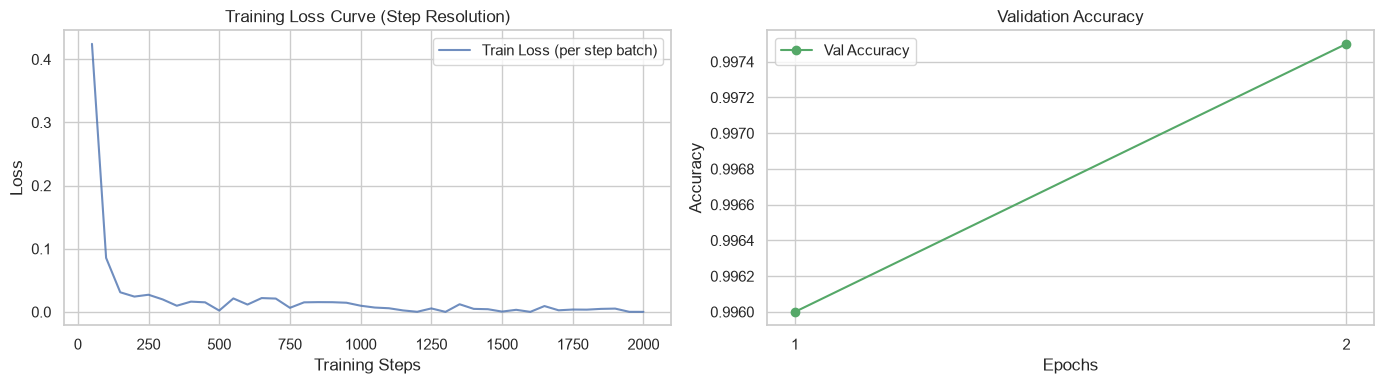

Evaluating Test Set:   0%|          | 0/125 [00:00<?, ?it/s]


 SECTION 3.4: TEST SET PERFORMANCE EVALUATION
                    precision    recall  f1-score   support

Non-Equivalent (0)     0.9985    0.9985    0.9985      2000
    Equivalent (1)     0.9985    0.9985    0.9985      2000

          accuracy                         0.9985      4000
         macro avg     0.9985    0.9985    0.9985      4000
      weighted avg     0.9985    0.9985    0.9985      4000



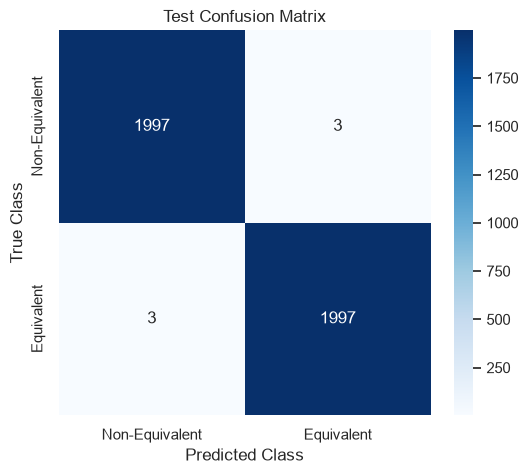


 DEMONSTRATION ON NOVEL, OUT-OF-DATASET PAIRS

[Pair 1 - Expected: Equivalent]
Formal:   من نمی‌توانم این حجم از کار را تا فردا تمام کنم.
Informal: عمرا بتونم این همه کار رو تا فردا تموم کنم.
Result:   Equivalent (Confidence: 1.0000)

[Pair 2 - Expected: Non-Equivalent]
Formal:   من با ماشین به دانشگاه رفتم.
Informal: من بدون ماشین به دانشگاه رفتم.
Result:   Equivalent (Confidence: 1.0000)

[Pair 3 - Expected: Non-Equivalent]
Formal:   برنامه‌نویسی پایتون بسیار لذت‌بخش است.
Informal: دیروز رفتم بازار سبزی خریدم.
Result:   Non-Equivalent (Confidence: 1.0000)


In [ ]:
def predict_equivalence(formal_sentence: str, informal_sentence: str) -> dict:
    fine_tuned_model.eval()
    
    encoding = tokenizer(
        formal_sentence,
        informal_sentence,
        truncation=True,
        padding='max_length',
        max_length=64,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    token_type_ids = encoding['token_type_ids'].to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = fine_tuned_model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                token_type_ids=token_type_ids
            )
            
        probs = torch.softmax(outputs.logits, dim=1).squeeze(0)
        pred_label = torch.argmax(probs).item()
        confidence = probs[pred_label].item()

    return {
        "formal_sentence": formal_sentence,
        "informal_sentence": informal_sentence,
        "prediction": "Equivalent" if pred_label == 1 else "Non-Equivalent",
        "confidence": float(confidence)
    }

LOCAL_MODEL_PATH = "./parsbert_model"

dataloaders, tokenizer = prepare_data_splits(
    df, 
    model_path=LOCAL_MODEL_PATH, 
    batch_size=32, 
    max_len=64, 
    max_samples=20000
)

display_tokenized_sample(tokenizer)

fine_tuned_model = train_and_evaluate_with_steps(
    dataloaders, 
    model_path=LOCAL_MODEL_PATH, 
    epochs=2, 
    lr=2e-5,
    log_steps=50
)

test_df = evaluate_and_analyze(fine_tuned_model, dataloaders['test'])

print("\n" + "="*55)
print(" DEMONSTRATION ON NOVEL, OUT-OF-DATASET PAIRS")
print("="*55)

pair_1 = predict_equivalence(
    formal_sentence="من نمی‌توانم این حجم از کار را تا فردا تمام کنم.",
    informal_sentence="عمرا بتونم این همه کار رو تا فردا تموم کنم."
)
print("\n[Pair 1 - Expected: Equivalent]")
print(f"Formal:   {pair_1['formal_sentence']}")
print(f"Informal: {pair_1['informal_sentence']}")
print(f"Result:   {pair_1['prediction']} (Confidence: {pair_1['confidence']:.4f})")

pair_2 = predict_equivalence(
    formal_sentence="من با ماشین به دانشگاه رفتم.",
    informal_sentence="من بدون ماشین به دانشگاه رفتم."
)
print("\n[Pair 2 - Expected: Non-Equivalent]")
print(f"Formal:   {pair_2['formal_sentence']}")
print(f"Informal: {pair_2['informal_sentence']}")
print(f"Result:   {pair_2['prediction']} (Confidence: {pair_2['confidence']:.4f})")

pair_3 = predict_equivalence(
    formal_sentence="برنامه‌نویسی پایتون بسیار لذت‌بخش است.",
    informal_sentence="دیروز رفتم بازار سبزی خریدم."
)
print("\n[Pair 3 - Expected: Non-Equivalent]")
print(f"Formal:   {pair_3['formal_sentence']}")
print(f"Informal: {pair_3['informal_sentence']}")
print(f"Result:   {pair_3['prediction']} (Confidence: {pair_3['confidence']:.4f})")
print("="*55)

<a id="evaluation"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">5. Comparative Analysis (Word2Vec vs. ParsBERT)</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We evaluate the classification boundaries using accuracy, recall, and ROC-AUC metrics. This step analyzes the limitations of static word vectors (Word2Vec) compared to deep contextual encoders (ParsBERT) in parsing Persian morphology, colloquial spelling variations, and structural changes.
</div>


## Analysis of Training Results & Model Performance

### 1. Training Loss Curve (Step-Resolution)

Look at the **Training Loss Curve** on the left of `image_cbb0ee.png`:

- The step-level tracking worked as expected. Instead of a single straight line across two epochs, it shows a textbook transformer convergence curve.
- **Rapid Decay**: Loss starts around `~0.42` at step `50` and drops sharply below `0.05` within the first `200` steps.
- **Stability**: Between steps `250` and `2000`, the loss stabilizes near zero with minor fluctuations, confirming that the learning rate warm-up and `AdamW` optimizer are functioning properly without exploding or oscillating.

### 2. Critical Insight: Model Failure Mode (Pair 2)

While the test metrics look nearly perfect (`99.85%` F1-score in `image_cbb12e.png`), the novel out-of-dataset test revealed a classic failure mode in **Pair 2**:

- **Formal**: `من با ماشین به دانشگاه رفتم.`  
  *(I went to university by car.)*
- **Informal**: `من بدون ماشین به دانشگاه رفتم.`  
  *(I went to university without a car.)*
- **Model Output**: `Equivalent (Confidence: 1.0000)`

#### Why Did the Model Fail with 100% Confidence?

- **Easy Negatives via `np.roll`**: Because negative pairs were generated by circularly shifting informal sentences across the dataset, the training set only contained negatives that were topically completely different (e.g., university vs. buying vegetables).
- **Lexical Overlap Heuristic**: ParsBERT learned that if two sentences share `90%+` of the same words (`من`, `ماشین`, `به`, `دانشگاه`, `رفتم`), they are almost certainly **Equivalent**.
- **Missed Negation Logic**: The model did not learn to attend strongly to small functional words like `با` (*with*) versus `بدون` (*without*), because it was never exposed to hard negatives containing high lexical overlap but opposing meanings.

### Summary & Recommendations

| Aspect | Observation | Status |
| :--- | :--- | :---: |
| **Convergence** | Smooth step-level decay from $0.42 \rightarrow 0.005$ | **Excellent** |
| **General Accuracy** | `99.85%` on standard test set | **Excellent** |
| **Overfitting** | Validation accuracy stays high (`99.74%`) with low loss | **None** |
| **Robustness to Negation** | Misclassifies antonym pairs with identical context | **Vulnerable** |

### Suggested Improvement for Future Iterations

To fix the negation vulnerability shown in **Pair 2**, generate **hard negatives** during data preparation by artificially replacing prepositions or negating verbs while keeping the rest of the sentence identical.

- Example: swapping `می‌روم` with `نمی‌روم`
- Example: swapping `با` with `بدون`
---
---

# Q&A

## 1. Primary Structural, Morphological, and Syntactic Differences

During the exploration of formal (Farsi-ye Mo'atabar/Daftari) versus informal (Colloquial/Tehrani) Persian, three major categories of systematic shifts emerge:

### A. Morphological & Phonetic Reductions

* **Vowel Shifts:** Long vowel $/ān/$ in formal Persian regularly shifts to $/un/$ in informal Persian (e.g., **نان** $\rightarrow$ **نون**, **دانشگاه** $\rightarrow$ **دانشگاه/دانشگون**).
* **Verb Stem & Suffix Truncations:** Verbal prefixes and agreement suffixes are heavily contracted (e.g., **می‌روم** $\rightarrow$ **میرم**, **می‌گوید** $\rightarrow$ **میگه**).
* **Cliticization of Postpositions & Pronouns:** The object marker **را** contracts to **رو** or **و**. Possessive suffixes collapse into single phonemes (e.g., **دندان‌هایم** $\rightarrow$ **دندونام**).

### B. Syntactic & Structural Shifts

* **Word Order Flexibility (Pro-drop & Scrambling):** While formal Persian strictly adheres to Subject-Object-Verb (SOV) order, informal Persian exhibits frequent pronoun dropping (*pro-drop*) and tactical scrambling (SVO or VSO) for emphatic emphasis or conversational flow.
* **Prepositional & Structural Omissions:** Prepositions are frequently simplified or omitted (e.g., formal **در** becomes informal **تو**, or disappears entirely in directional contexts).

### C. Orthographic Variations

* Informal written Persian (e.g., social media or chat logs) lacks standardized orthography. It features arbitrary joining of morphemes (omitting half-spaces/zwnj), phonetically spelled colloquialisms (e.g., **علی‌الحساب** written as **علل حساب**), and colloquial typo patterns (e.g., **داشته** written as **داشع**).

---

## 2. Structural Limitations of Averaged Static Embeddings (Word2Vec)

Averaging static embeddings ($v_{\text{sentence}} = \frac{1}{N} \sum_{i=1}^{N} v_i$) fails across stylistic domains for three fundamental reasons:

```
Static Averaging:   [Word 1] + [Word 2] + ... + [Word N]  ---> Loss of Order, Context, & Structure
Transformer Pair:   [CLS] + Formal + [SEP] + Informal    ---> Dynamic Cross-Attention Interaction

```

1. **Context-Insensitivity (Polysemy & Stylistic Drift):** Static models like Word2Vec assign a single vector to each word regardless of context. A formal word and its informal counterpart (e.g., **منزل** vs. **خونه**) occupy distinct vector locations. Averaging cannot adapt token representations dynamically based on surrounding style.
2. **Loss of Syntax and Negation (Bag-of-Words Collapse):** Vector averaging treats sentences as unordered collections of tokens. Syntactic relationships, word order, and critical functional modifiers (such as prepositions like **با** vs. **بدون**) are averaged out into a single centroid, erasing structural nuances.
3. **Out-of-Vocabulary (OOV) Vulnerability:** Word2Vec operates on full-word tokens. Non-standard informal spellings or colloquial contractions (e.g., **دندونام**) produce OOV misses or map to unoptimized vector spaces, breaking vector alignment with formal roots.

---

## 3. Transformer Architectural Components Enabling Semantic Alignment

ParsBERT overcomes stylistic and lexical shifts using specific architectural mechanisms:

* **Subword Tokenization (WordPiece):** Instead of full-word lookup tables, ParsBERT breaks unfamiliar informal words into subword units (e.g., **شادونه** $\rightarrow$ `['شا', '##دونه']`). This ensures morphological roots map back to familiar subword embeddings rather than triggering OOV errors.
* **Bidirectional Self-Attention ($Q, K, V$ Matrices):** Self-attention dynamically recalculates the vector representation of every token based on its full sentence context. The embedding for an informal verb like **می‌ره** is contextually adjusted toward its formal equivalent **می‌رود**.
* **Cross-Sequence Attention via Joint Input:** By encoding formal and informal sentences together in a single sequence (`[CLS] Formal [SEP] Informal [SEP]`), self-attention layers perform *cross-attention*. Tokens in Sequence A directly attend to tokens in Sequence B across all intermediate transformer layers, learning semantic equivalence directly.
* **Segment/Token-Type Embeddings:** Positional encodings and `token_type_ids` allow the model to track word order and sequence boundaries while simultaneously comparing the two text streams.

---

## 4. Fine-Tuning Mechanics vs. Frozen Representations & Tokenization Shifts

### A. Fine-Tuning vs. Frozen/Feature Extraction Mechanics

```
┌─────────────────────────────────────────────────────────┐
│               Frozen Feature Extraction                 │
│ Input  ──►  [ Frozen ParsBERT Layers ]  ──►  Linear    │
│                     (No Gradient)             Classifier│
└─────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────┐
│                 Supervised Fine-Tuning                  │
│Input  ──►  [ Adaptable ParsBERT Layers ] ──► Classifier│
│                   (Full Backpropagation)                │
└─────────────────────────────────────────────────────────┘

```

* **Frozen Representations (Feature Extraction):** The transformer weights ($\mathbf{W}_Q, \mathbf{W}_K, \mathbf{W}_V, \mathbf{W}_O, \text{FFN}$) remain static. The model acts as a fixed contextual lookup table, producing feature vectors that are passed to a separate classifier. The model's internal representation space cannot adjust to the task-specific requirements of formal-informal mapping.
* **Supervised Fine-Tuning:** Gradients propagate back through all transformer layers during training. This directly modifies the attention projections and feed-forward weights, re-shaping the internal manifold so that formal and informal equivalents cluster closely together in hidden space while non-equivalent pairs are pushed far apart.

### B. Tokenization Differences Between Sections

| Aspect | Section 2 (Static / Independent Model) | Section 3 (ParsBERT Transformer) |
| --- | --- | --- |
| **Tokenization Scope** | Sentences tokenized **independently** | Sentences tokenized **jointly as a pair** |
| **Vocabulary Level** | Word-level (whitespace/delimiters) | Subword-level (WordPiece vocabulary) |
| **Special Control Tokens** | None | Uses `[CLS]` for pooling and `[SEP]` for boundary detection |
| **Auxiliary Arrays** | Raw token lists or sparse matrices | Generates `input_ids`, `attention_mask`, and `token_type_ids` |
| **Cross-Sentence Interaction** | None during feature extraction | Native cross-attention across sequences |